# Project 1 — Customer Segmentation Using Clustering

Customer segmentation is a typical unsupervised learning problem: there is no column that tells us the “correct” customer segment. Instead, we construct meaningful customer-level features and search for groups that are internally similar and externally different.

The important idea in this notebook is that clustering is not a magic label generator. A useful segmentation should be statistically reasonable, stable under sensible modeling choices, and interpretable enough to support business decisions.

## Prerequisites

This notebook assumes basic familiarity with pandas, NumPy, plotting, and descriptive statistics. A basic intuition about distance is helpful because many clustering methods compare customers by how close their feature vectors are.

A train/test split is not central here because we are not training a supervised predictor. The workflow is more exploratory: feature construction, scaling, clustering, visualization, and interpretation.

## Problem statement

Given raw transaction-level data, create customer-level behavioral features and group customers into meaningful segments.

The raw data has one row per transaction line, not one row per customer. A customer may appear in many invoices and buy many products, so clustering the raw rows directly would mix product-level and customer-level information. We first aggregate transactions into RFM-style customer features.

## Dataset description and source

We use the **UCI Online Retail** dataset, which contains transactions from a UK-based online retail store. The columns include invoice number, product code and description, quantity, invoice date, unit price, customer ID, and country.

The dataset contains cancellations, missing customer IDs, and transaction rows that must be cleaned before customer-level segmentation. Revenue is not directly supplied; it is constructed as `Quantity × UnitPrice`.

The notebook loads the dataset directly from the UCI repository at runtime, so no local Excel file is required.

In [1]:
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

In [2]:
from pathlib import Path
import urllib.request

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
DATA_PATH = Path("online_retail_uci.xlsx")

if not DATA_PATH.exists():
    print("Downloading UCI Online Retail dataset. This may take a little time the first time.")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

retail = pd.read_excel(DATA_PATH)
print(retail.shape)
retail.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Initial inspection

Before cleaning or modeling, we inspect the shape, data types, missing values, unique customers, invoices, products, and date range. This step helps us understand whether the data is suitable for customer-level analysis and which cleaning choices are necessary.

For example, missing `CustomerID` values are not useful for customer segmentation because they cannot be assigned to a known customer. Cancelled invoices also need attention because they represent reversals rather than normal purchases.

In [3]:
display(retail.info())
display(retail.isna().sum().sort_values(ascending=False))

summary = {
    "rows": len(retail),
    "unique_invoices": retail["InvoiceNo"].nunique(),
    "unique_customers": retail["CustomerID"].nunique(dropna=True),
    "unique_products": retail["StockCode"].nunique(),
    "date_min": retail["InvoiceDate"].min(),
    "date_max": retail["InvoiceDate"].max(),
    "countries": retail["Country"].nunique()
}
pd.Series(summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

rows                             541909
unique_invoices                   25900
unique_customers                   4372
unique_products                    4070
date_min            2010-12-01 08:26:00
date_max            2011-12-09 12:50:00
countries                            38
dtype: object

## Cleaning transaction data

The segmentation should be based on real purchasing behavior. Rows with missing customer IDs, cancelled invoices, non-positive quantities, or non-positive unit prices can distort customer profiles. These cleaning decisions are not just technical; they define what kind of behavior the segmentation represents.

Here, we keep completed positive purchases from identifiable customers and construct `Revenue`.

In [4]:
df = retail.copy()

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[df["CustomerID"].notna()]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(df.shape)
df.head()

(397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## RFM feature construction

RFM summarizes three behavioral dimensions:

- **Recency**: how many days have passed since the customer’s last purchase.
- **Frequency**: how many distinct invoices the customer generated.
- **Monetary value**: total spending by the customer.

RFM is popular because it compresses transaction history into a small number of interpretable variables. It is not the only possible representation; product category preference, seasonality, profit margin, and browsing behavior could add more detail if available.

In [5]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
          Frequency=("InvoiceNo", "nunique"),
          Monetary=("Revenue", "sum"),
          AvgOrderValue=("Revenue", lambda x: x.sum() / df.loc[x.index, "InvoiceNo"].nunique()),
          TotalQuantity=("Quantity", "sum"),
          ProductDiversity=("StockCode", "nunique"),
          TenureDays=("InvoiceDate", lambda x: (x.max() - x.min()).days + 1)
      )
)

rfm = rfm.replace([np.inf, -np.inf], np.nan).dropna()
print(rfm.shape)
rfm.head()

(4338, 7)


,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ProductDiversity,TenureDays
CustomerID,,,,,,,
12346,326,1,77183.60,77183.600000,74215,1,1
12347,2,7,4310.00,615.714286,2458,103,366
12348,75,4,1797.24,449.310000,2341,22,283
12349,19,1,1757.55,1757.550000,631,73,1
12350,310,1,334.40,334.400000,197,17,1


## Distribution of customer features

Customer spending and purchase frequency are usually highly skewed: many customers buy a little, while a small number buy a lot. Skewness matters because distance-based clustering can be dominated by extreme values.

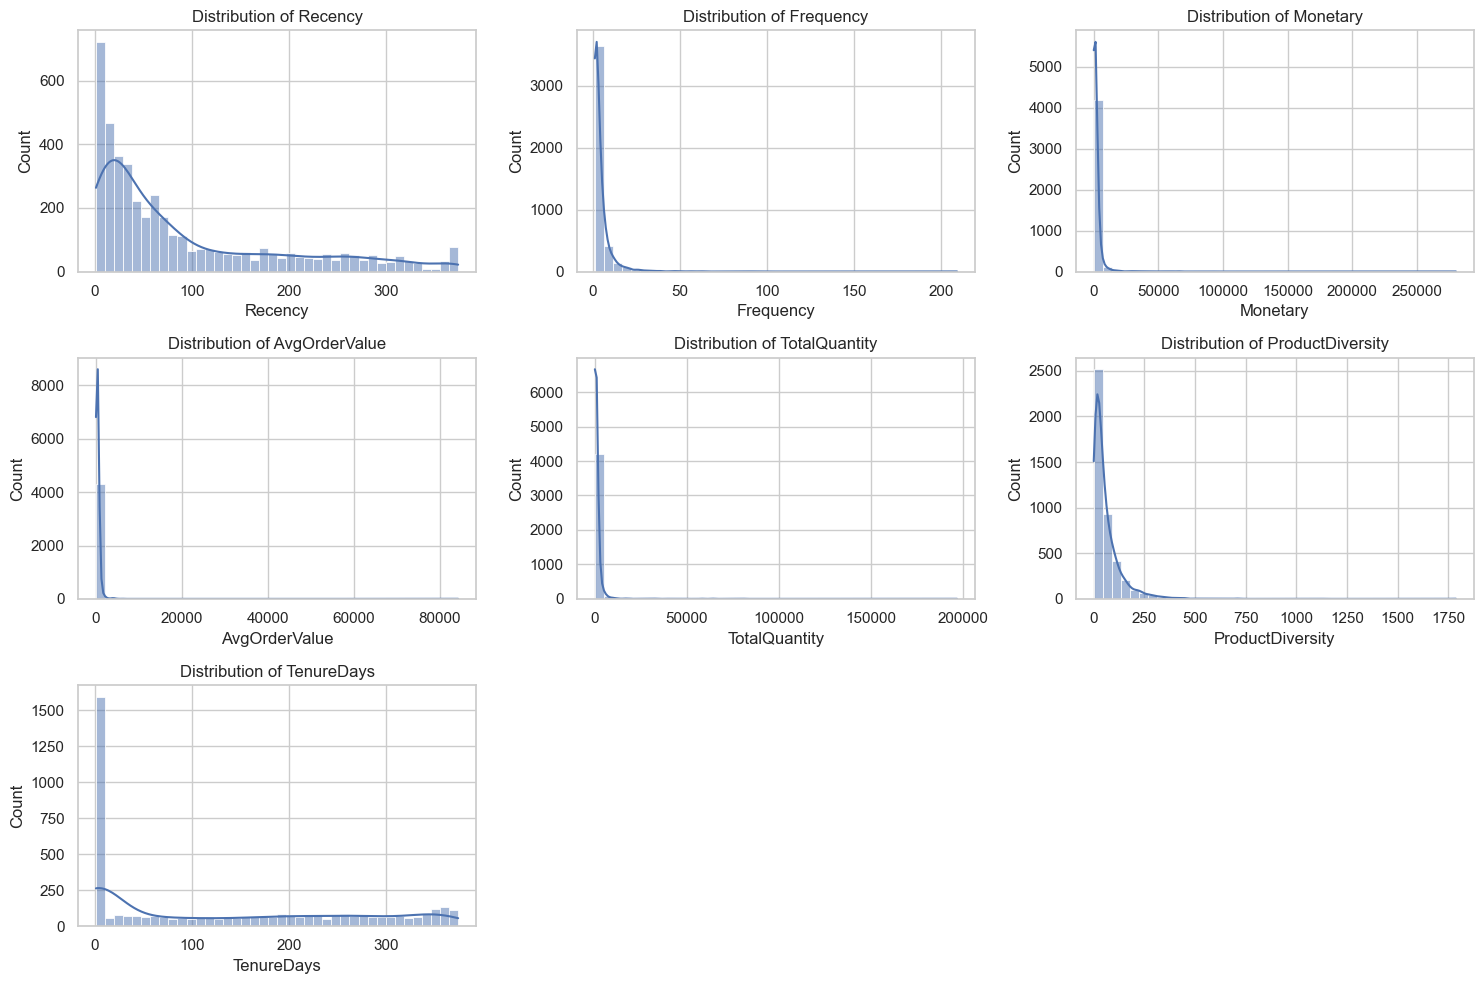

In [6]:
features = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "TotalQuantity", "ProductDiversity", "TenureDays"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.histplot(rfm[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Transformation and scaling

K-Means, hierarchical clustering, and DBSCAN use distances. If `Monetary` has values in thousands while `Recency` is in days, the larger-scale variable can dominate the distance calculation. A log transform reduces skewness, and scaling makes variables comparable.

This does not make the data “correct”; it makes the distance geometry closer to the behavioral comparison we intend.

In [7]:
rfm_log = rfm.copy()
skewed_cols = ["Frequency", "Monetary", "AvgOrderValue", "TotalQuantity", "ProductDiversity", "TenureDays"]

for col in skewed_cols:
    rfm_log[col] = np.log1p(rfm_log[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_log[features])

rfm_scaled = pd.DataFrame(X_scaled, index=rfm.index, columns=features)
rfm_scaled.describe().round(3)

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ProductDiversity,TenureDays
count,4338.000,4338.000,4338.000,4338.000,4338.000,4338.000,4338.000
mean,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.915,-0.955,-4.005,-5.584,-3.864,-2.526,-1.269
25%,-0.745,-0.955,-0.686,-0.618,-0.660,-0.635,-1.269
50%,-0.415,-0.362,-0.062,0.048,-0.034,0.028,0.475
75%,0.495,0.653,0.654,0.558,0.668,0.712,0.922
max,2.815,5.859,4.732,7.641,4.529,3.480,1.098


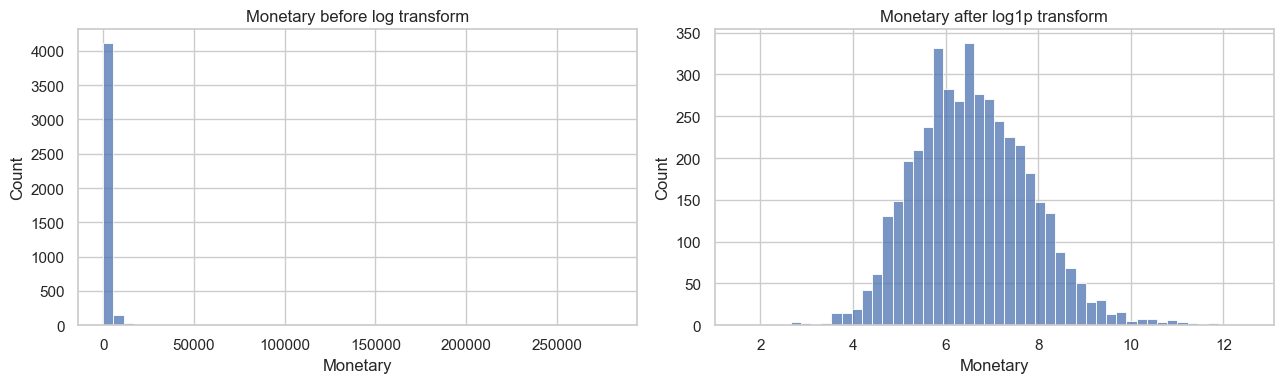

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(rfm["Monetary"], bins=50, ax=axes[0])
axes[0].set_title("Monetary before log transform")

sns.histplot(rfm_log["Monetary"], bins=50, ax=axes[1])
axes[1].set_title("Monetary after log1p transform")

plt.tight_layout()
plt.show()

## Scaling effect experiment with K-Means

A useful way to see why preprocessing matters is to run the same clustering model before and after scaling. The comparison below does not tell us which segmentation is “true”; it shows how strongly numerical scale can shape the clusters.

In [9]:
def kmeans_summary(X, k=4, label="model"):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    counts = pd.Series(labels).value_counts().sort_index()
    return {"setting": label, "silhouette": sil, "cluster_sizes": counts.to_dict()}

unscaled_log = rfm_log[features].values

scale_comparison = pd.DataFrame([
    kmeans_summary(unscaled_log, k=4, label="log transformed but not scaled"),
    kmeans_summary(X_scaled, k=4, label="log transformed and scaled")
])
scale_comparison

,setting,silhouette,cluster_sizes
0,log transformed but not scaled,0.60888,"{0: 2188, 1: 498, 2: 603, 3: 1049}"
1,log transformed and scaled,0.27109,"{0: 932, 1: 1499, 2: 1116, 3: 791}"


## K-Means clustering

K-Means is a centroid-based method. It chooses `k` centroids and repeatedly alternates between assigning each point to the nearest centroid and updating centroids as the mean of assigned points.

It works best when clusters are roughly compact and spherical in the feature space. Its important hyperparameters include the number of clusters `k`, initialization strategy, and `n_init`, the number of independent initializations used to reduce the risk of a poor local solution.

In [10]:
k_values = range(2, 11)
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

kmeans_results = pd.DataFrame(rows)
kmeans_results

,k,inertia,silhouette
0,2,17204.625155,0.372520
1,3,13917.841689,0.273350
2,4,11737.859794,0.271202
3,5,10490.226578,0.273794
4,6,9400.725181,0.249425
5,7,8635.303212,0.249344
6,8,8024.113060,0.241986
7,9,7533.835956,0.235702
8,10,7137.138120,0.234976


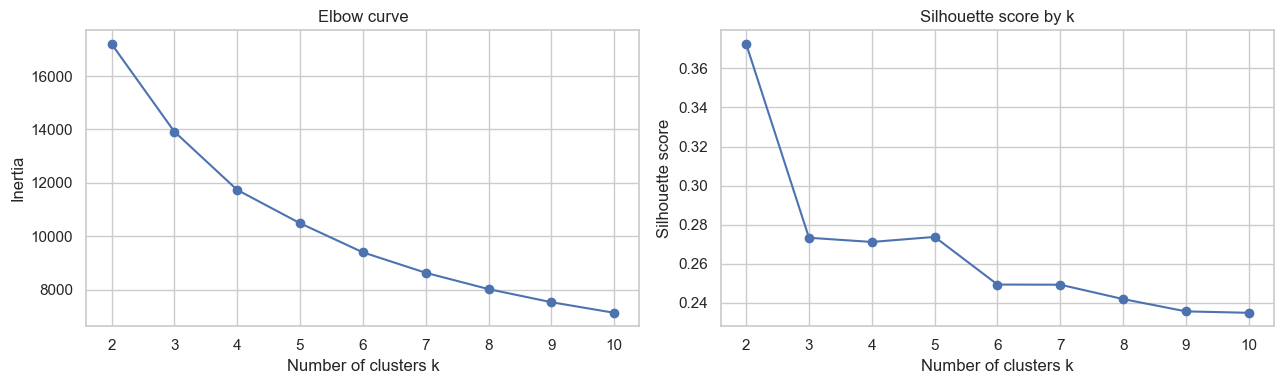

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
axes[0].set_title("Elbow curve")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

The elbow method asks where adding more clusters gives diminishing reduction in inertia. The silhouette score asks whether points are closer to their own cluster than to other clusters. Both are guides, not final answers. In customer segmentation, interpretability and actionability matter as much as a metric.

### Turning the K-Means diagnostic curves into a defensible choice

The elbow and silhouette plots are useful, but they can still leave more than one reasonable value of `k`. A practical way to avoid choosing a cluster count only by visual impression is to summarize three signals together: silhouette, inertia reduction, and cluster balance. A good educational notebook should make this reasoning visible, because in real segmentation work the final choice is usually a compromise between statistical separation and business interpretability.

In [12]:
k_diagnostic = kmeans_results.copy()
k_diagnostic["inertia_reduction_from_previous_k"] = -k_diagnostic["inertia"].diff()
k_diagnostic["relative_inertia_reduction_%"] = 100 * k_diagnostic["inertia_reduction_from_previous_k"] / k_diagnostic["inertia"].shift(1)

balance_rows = []
for k in k_values:
    km_tmp = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels_tmp = km_tmp.fit_predict(X_scaled)
    counts = pd.Series(labels_tmp).value_counts(normalize=True)
    balance_rows.append({
        "k": k,
        "smallest_cluster_%": 100 * counts.min(),
        "largest_cluster_%": 100 * counts.max(),
        "cluster_size_ratio_largest_to_smallest": counts.max() / counts.min()
    })

k_diagnostic = k_diagnostic.merge(pd.DataFrame(balance_rows), on="k")
display(k_diagnostic.round(3))

best_sil_k = int(k_diagnostic.loc[k_diagnostic["silhouette"].idxmax(), "k"])
print(f"Highest silhouette among tested values occurs at k={best_sil_k}.")
print("This is a statistical suggestion, not an automatic business decision; inspect profiles before finalizing k.")

,k,inertia,silhouette,inertia_reduction_from_previous_k,relative_inertia_reduction_%,smallest_cluster_%,largest_cluster_%,cluster_size_ratio_largest_to_smallest
0,2,17204.625,0.373,NaN,NaN,48.317,51.683,1.070
1,3,13917.842,0.273,3286.783,19.104,25.473,38.382,1.507
2,4,11737.860,0.271,2179.982,15.663,18.280,34.532,1.889
3,5,10490.227,0.274,1247.633,10.629,13.071,34.463,2.637
4,6,9400.725,0.249,1089.501,10.386,10.420,27.294,2.619
5,7,8635.303,0.249,765.422,8.142,6.270,26.441,4.217
6,8,8024.113,0.242,611.190,7.078,5.486,23.029,4.197
7,9,7533.836,0.236,490.277,6.110,5.602,22.038,3.934
8,10,7137.138,0.235,396.698,5.266,4.541,21.646,4.766


Highest silhouette among tested values occurs at k=2.
This is a statistical suggestion, not an automatic business decision; inspect profiles before finalizing k.


## Initialization sensitivity

K-Means can converge to different local solutions because the initial centroids can differ. Increasing `n_init` makes the algorithm try several starting points and keep the best solution according to inertia.

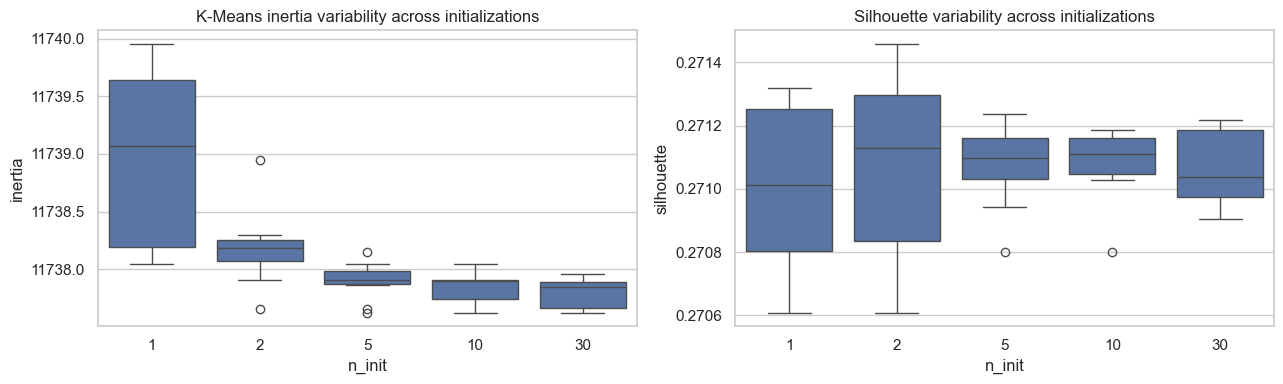

In [13]:
init_rows = []
for n_init in [1, 2, 5, 10, 30]:
    for seed in range(10):
        km = KMeans(n_clusters=4, n_init=n_init, random_state=seed)
        labels = km.fit_predict(X_scaled)
        init_rows.append({
            "n_init": n_init,
            "seed": seed,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_scaled, labels)
        })

init_df = pd.DataFrame(init_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=init_df, x="n_init", y="inertia", ax=axes[0])
axes[0].set_title("K-Means inertia variability across initializations")
sns.boxplot(data=init_df, x="n_init", y="silhouette", ax=axes[1])
axes[1].set_title("Silhouette variability across initializations")
plt.tight_layout()
plt.show()

## K-Means cluster profiling

After choosing a working value of `k`, we examine cluster profiles in the original feature scale. This is where clustering becomes useful: segments should be interpretable in terms of recency, frequency, monetary value, and related customer behavior.

The names assigned to clusters are interpretations. They should be treated as practical summaries, not ground truth labels.

In [14]:
SELECTED_K = 4

kmeans = KMeans(n_clusters=SELECTED_K, n_init=30, random_state=RANDOM_STATE)
rfm_profile = rfm.copy()
rfm_profile["KMeansCluster"] = kmeans.fit_predict(X_scaled)

cluster_profile_mean = rfm_profile.groupby("KMeansCluster")[features].mean().round(2)
cluster_profile_median = rfm_profile.groupby("KMeansCluster")[features].median().round(2)
cluster_sizes = rfm_profile["KMeansCluster"].value_counts().sort_index()

display(cluster_sizes.rename("cluster_size"))
display(cluster_profile_mean)
display(cluster_profile_median)

0    1118
1     793
2    1498
3     929
Name: cluster_size, dtype: int64

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ProductDiversity,TenureDays
KMeansCluster,,,,,,,
0,30.41,10.48,6265.50,727.93,3622.52,141.88,267.91
1,192.07,1.24,167.77,144.03,87.32,11.05,12.43
2,63.38,3.21,823.44,276.25,492.79,47.45,172.73
3,129.35,1.10,581.29,512.88,334.11,30.49,2.26


,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,ProductDiversity,TenureDays
KMeansCluster,,,,,,,
0,17.0,7.0,2932.41,419.72,1752.0,110.0,290.0
1,202.0,1.0,151.42,134.10,75.0,9.0,1.0
2,40.0,3.0,745.94,242.94,417.5,39.0,170.0
3,82.0,1.0,390.07,365.27,235.0,24.0,1.0


### Data-driven cluster interpretation helper

The table above is the main evidence for naming clusters. The following helper does not create final segment names automatically; it only marks whether each cluster is relatively high, medium, or low on each behavioral feature. This keeps the interpretation grounded in the executed output and reduces the chance of assigning attractive but unsupported business labels.

In [15]:
def relative_level(series):
    q1, q2 = series.quantile([0.33, 0.66])
    return pd.cut(series, bins=[-np.inf, q1, q2, np.inf], labels=["low", "medium", "high"])

interpretation_helper = cluster_profile_median.copy()
for col in features:
    interpretation_helper[col + "_relative_level"] = relative_level(cluster_profile_median[col])

relative_cols = [c for c in interpretation_helper.columns if c.endswith("_relative_level")]
display(interpretation_helper[relative_cols])

print("Interpretation tip: clusters with low Recency are more recent customers; high Monetary/Frequency usually indicates stronger purchase value or loyalty.")

,Recency_relative_level,Frequency_relative_level,Monetary_relative_level,AvgOrderValue_relative_level,TotalQuantity_relative_level,ProductDiversity_relative_level,TenureDays_relative_level
KMeansCluster,,,,,,,
0,low,high,high,high,high,high,high
1,high,low,low,low,low,low,low
2,medium,high,high,medium,high,high,high
3,high,low,medium,high,medium,medium,low


Interpretation tip: clusters with low Recency are more recent customers; high Monetary/Frequency usually indicates stronger purchase value or loyalty.


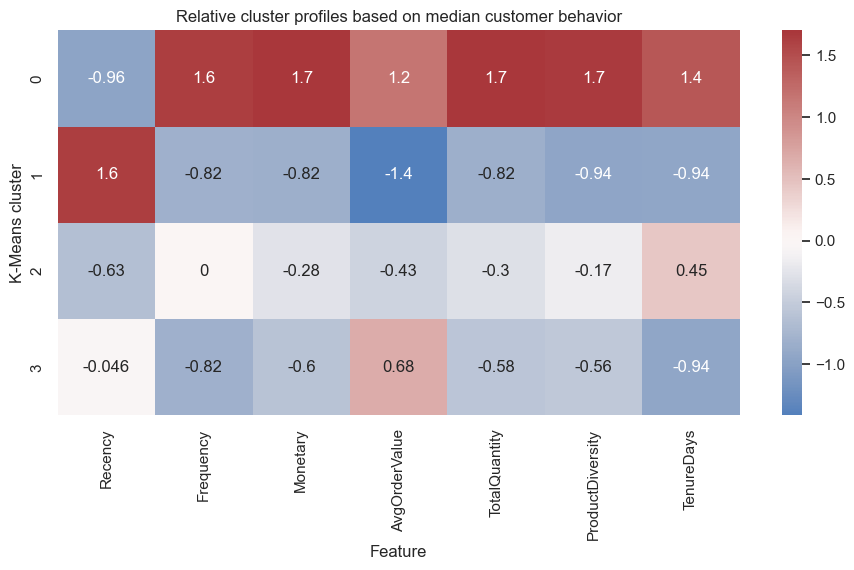

In [16]:
profile_for_plot = cluster_profile_median.copy()
profile_scaled_for_plot = pd.DataFrame(
    StandardScaler().fit_transform(profile_for_plot),
    index=profile_for_plot.index,
    columns=profile_for_plot.columns
)

plt.figure(figsize=(11, 5))
sns.heatmap(profile_scaled_for_plot, annot=True, cmap="vlag", center=0)
plt.title("Relative cluster profiles based on median customer behavior")
plt.xlabel("Feature")
plt.ylabel("K-Means cluster")
plt.show()

## PCA visualization of K-Means clusters

PCA projects the scaled customer features into two directions that capture as much variance as possible. This helps us visualize the segmentation, but it is still only a 2D projection. If clusters overlap here, they may still differ in the full feature space.

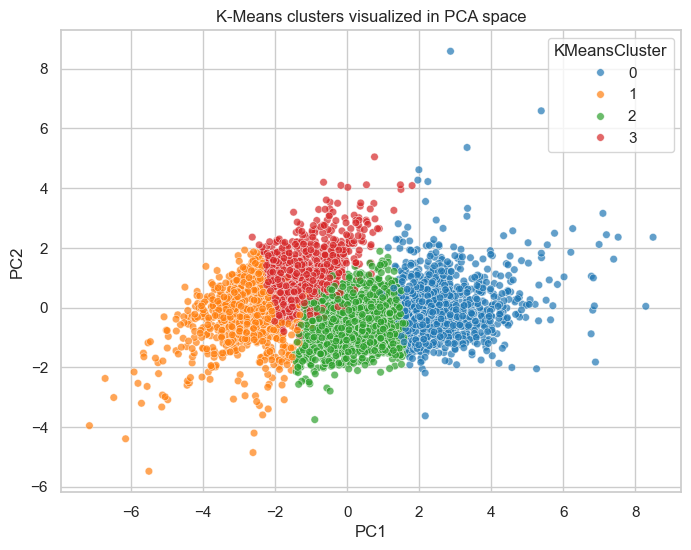

Explained variance ratio: [0.63623462 0.16562892]


In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=rfm.index)
pca_df["KMeansCluster"] = rfm_profile["KMeansCluster"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="KMeansCluster", palette="tab10", s=30, alpha=0.7)
plt.title("K-Means clusters visualized in PCA space")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## Hierarchical clustering

Agglomerative hierarchical clustering starts with each customer as a separate cluster and repeatedly merges the closest groups. The merge pattern creates a tree called a dendrogram.

Linkage controls how the distance between two groups is measured. Single linkage can create chain-like clusters, complete linkage favors compact clusters, average linkage balances pairwise distances, and Ward linkage merges groups that minimally increase within-cluster variance.

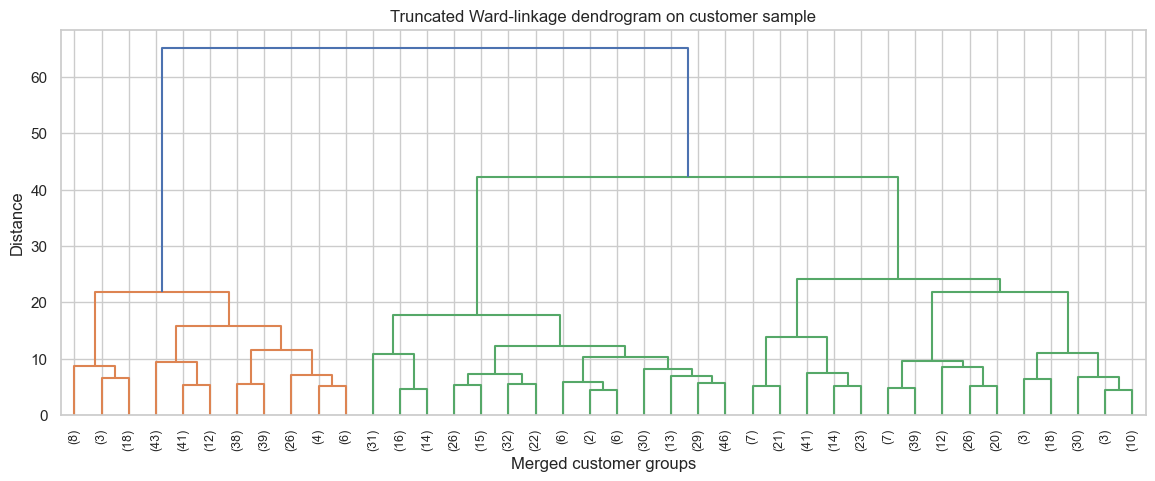

In [18]:
# Dendrograms are expensive and visually crowded on thousands of customers.
# We use a reproducible sample for the tree visualization.
sample_size = min(800, len(rfm_scaled))
sample_idx = rfm_scaled.sample(sample_size, random_state=RANDOM_STATE).index
X_sample = rfm_scaled.loc[sample_idx].values

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=40, leaf_rotation=90, leaf_font_size=9)
plt.title("Truncated Ward-linkage dendrogram on customer sample")
plt.xlabel("Merged customer groups")
plt.ylabel("Distance")
plt.show()

In [19]:
def make_agglomerative(n_clusters, linkage_method):
    # sklearn changed the argument name from affinity to metric in newer versions.
    if linkage_method == "ward":
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method)
    try:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric="euclidean")
    except TypeError:
        return AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, affinity="euclidean")

hier_rows = []
for linkage_method in ["ward", "complete", "average", "single"]:
    for k in [3, 4, 5, 6]:
        model = make_agglomerative(k, linkage_method)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels) if len(np.unique(labels)) > 1 else np.nan
        hier_rows.append({
            "linkage": linkage_method,
            "n_clusters": k,
            "silhouette": sil,
            "min_cluster_size": pd.Series(labels).value_counts().min(),
            "max_cluster_size": pd.Series(labels).value_counts().max()
        })

hier_results = pd.DataFrame(hier_rows)
hier_results.sort_values("silhouette", ascending=False)

,linkage,n_clusters,silhouette,min_cluster_size,max_cluster_size
13,single,4,0.529918,1,4334
12,single,3,0.529339,1,4336
14,single,5,0.514624,1,4334
8,average,3,0.422061,4,4267
15,single,6,0.378707,1,4333
9,average,4,0.294780,4,4223
10,average,5,0.274107,2,4221
11,average,6,0.272240,1,4221
1,ward,4,0.247446,422,1878
0,ward,3,0.239058,883,1878


Hierarchical clustering is useful when the nested structure itself matters, but it can be computationally expensive and sensitive to linkage choice. For large customer databases, it is often used on samples or as an exploratory complement to faster methods.

## DBSCAN

DBSCAN is density-based. It groups points that have enough neighbors within a radius `eps` and labels isolated points as noise. It does not require choosing the number of clusters in advance.

The two central hyperparameters are:

- `eps`: neighborhood radius.
- `min_samples`: minimum number of points required to form a dense region.

DBSCAN is very sensitive to scaling and to the value of `eps`, especially when the data has uneven densities.

### A k-distance plot before choosing `eps`

DBSCAN is especially sensitive to `eps`. Instead of trying values blindly, a common diagnostic is the sorted distance to the `min_samples`-th nearest neighbor. A sharp bend in the curve often indicates a transition between dense regions and sparse/noisy points. The bend is still subjective, but it gives a more principled starting point for the `eps` experiment below.

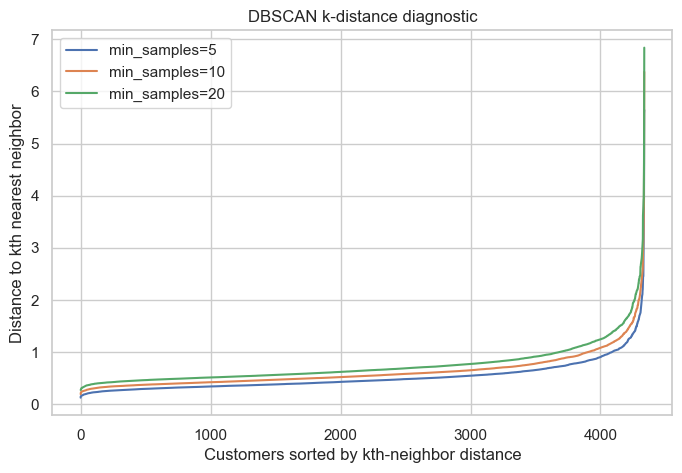

In [20]:
from sklearn.neighbors import NearestNeighbors

for min_samples_for_curve in [5, 10, 20]:
    nn = NearestNeighbors(n_neighbors=min_samples_for_curve)
    nn.fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    kth_distances = np.sort(distances[:, -1])
    plt.plot(kth_distances, label=f"min_samples={min_samples_for_curve}")

plt.title("DBSCAN k-distance diagnostic")
plt.xlabel("Customers sorted by kth-neighbor distance")
plt.ylabel("Distance to kth nearest neighbor")
plt.legend()
plt.show()

In [21]:
dbscan_rows = []

for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_samples in [5, 10, 20]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        unique = set(labels)
        n_noise = np.sum(labels == -1)
        n_clusters = len(unique - {-1})
        if n_clusters >= 2 and np.sum(labels != -1) > n_clusters:
            sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        else:
            sil = np.nan
        dbscan_rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_percent": 100 * n_noise / len(labels),
            "silhouette_non_noise": sil
        })

dbscan_results = pd.DataFrame(dbscan_rows)
dbscan_results

,eps,min_samples,n_clusters,noise_percent,silhouette_non_noise
0,0.5,5,10,25.841402,-0.018229
1,0.5,10,4,37.920701,0.180017
2,0.5,20,4,54.264638,0.183021
3,0.8,5,4,6.546796,-0.073719
4,0.8,10,1,10.073767,NaN
5,0.8,20,2,13.024435,0.408551
6,1.0,5,2,3.204242,0.480786
7,1.0,10,1,4.472107,NaN
8,1.0,20,1,5.901337,NaN
9,1.2,5,1,1.682803,NaN


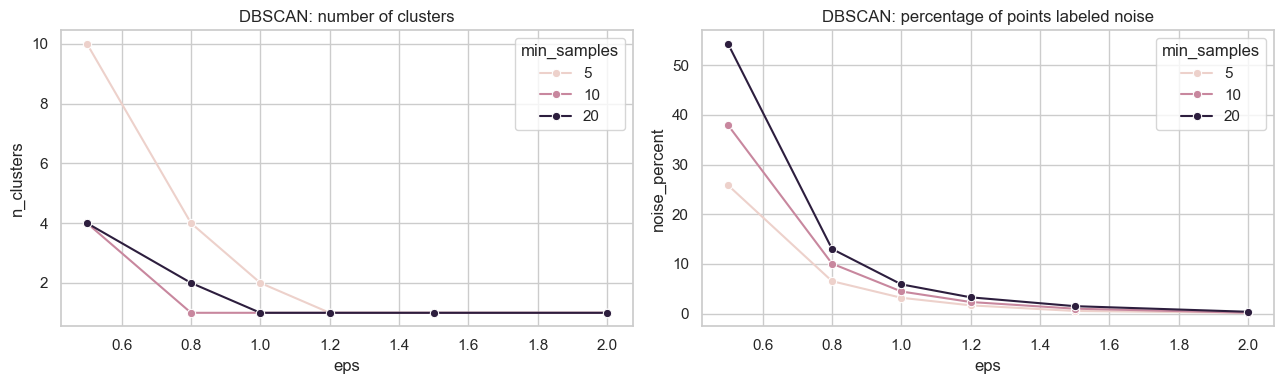

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=dbscan_results, x="eps", y="n_clusters", hue="min_samples", marker="o", ax=axes[0])
axes[0].set_title("DBSCAN: number of clusters")

sns.lineplot(data=dbscan_results, x="eps", y="noise_percent", hue="min_samples", marker="o", ax=axes[1])
axes[1].set_title("DBSCAN: percentage of points labeled noise")

plt.tight_layout()
plt.show()

## Comparing clustering methods

The comparison table below is intentionally practical. It focuses on the number of discovered clusters, noise handling, silhouette score, and interpretability notes. A high silhouette score is useful, but it does not automatically imply a useful business segmentation.

### Stability check for K-Means segment structure

A segmentation is more trustworthy if small changes in the data do not radically change the grouping. The next experiment repeatedly fits K-Means on overlapping subsamples and compares the labels assigned to customers that appear in both subsamples. Adjusted Rand Index close to 1 means the two runs give very similar partitions on the overlapping customers; values near 0 mean agreement is close to chance.

,mean,std,min,max
k,,,,
3,0.971,0.019,0.945,0.996
4,0.948,0.028,0.909,0.986
5,0.834,0.104,0.698,0.980
6,0.895,0.082,0.730,0.979


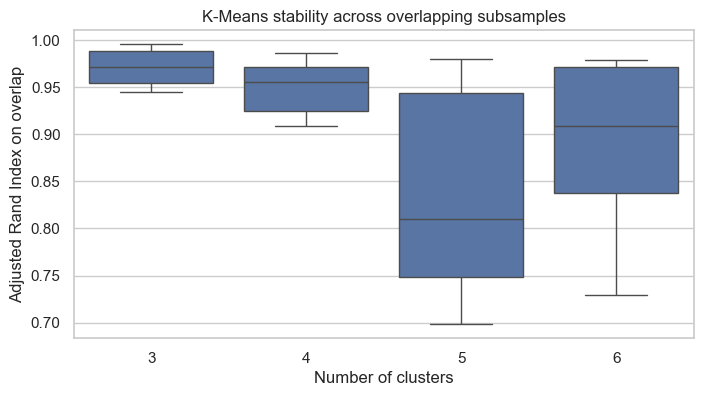

In [23]:
from sklearn.metrics import adjusted_rand_score

rng = np.random.default_rng(RANDOM_STATE)
stability_rows = []
all_positions = np.arange(X_scaled.shape[0])

for k in [3, 4, 5, 6]:
    for repeat in range(12):
        idx_a = rng.choice(all_positions, size=int(0.80 * len(all_positions)), replace=False)
        idx_b = rng.choice(all_positions, size=int(0.80 * len(all_positions)), replace=False)
        common = np.intersect1d(idx_a, idx_b)
        km_a = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE + repeat).fit(X_scaled[idx_a])
        km_b = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE + 100 + repeat).fit(X_scaled[idx_b])
        labels_a_common = km_a.predict(X_scaled[common])
        labels_b_common = km_b.predict(X_scaled[common])
        stability_rows.append({
            "k": k,
            "repeat": repeat,
            "overlap_size": len(common),
            "ARI_on_overlap": adjusted_rand_score(labels_a_common, labels_b_common)
        })

stability_df = pd.DataFrame(stability_rows)
display(stability_df.groupby("k")["ARI_on_overlap"].agg(["mean", "std", "min", "max"]).round(3))

plt.figure(figsize=(8, 4))
sns.boxplot(data=stability_df, x="k", y="ARI_on_overlap")
plt.title("K-Means stability across overlapping subsamples")
plt.xlabel("Number of clusters")
plt.ylabel("Adjusted Rand Index on overlap")
plt.show()

In [24]:
comparison_rows = []

km_labels = rfm_profile["KMeansCluster"].values
comparison_rows.append({
    "Method": "K-Means",
    "Key hyperparameters": f"k={SELECTED_K}, n_init=30",
    "Number of clusters": len(np.unique(km_labels)),
    "Noise %": 0.0,
    "Silhouette": silhouette_score(X_scaled, km_labels),
    "Interpretability note": "Centroid-based segments; easy to profile with RFM means/medians."
})

best_h = hier_results.sort_values("silhouette", ascending=False).iloc[0]
h_model = make_agglomerative(int(best_h["n_clusters"]), best_h["linkage"])
h_labels = h_model.fit_predict(X_scaled)
comparison_rows.append({
    "Method": "Hierarchical",
    "Key hyperparameters": f"linkage={best_h['linkage']}, k={int(best_h['n_clusters'])}",
    "Number of clusters": len(np.unique(h_labels)),
    "Noise %": 0.0,
    "Silhouette": silhouette_score(X_scaled, h_labels),
    "Interpretability note": "Tree-based view; useful for exploring nested customer structure."
})

valid_db = dbscan_results.dropna(subset=["silhouette_non_noise"])
if len(valid_db) > 0:
    best_db = valid_db.sort_values("silhouette_non_noise", ascending=False).iloc[0]
    db = DBSCAN(eps=float(best_db["eps"]), min_samples=int(best_db["min_samples"]))
    db_labels = db.fit_predict(X_scaled)
    comparison_rows.append({
        "Method": "DBSCAN",
        "Key hyperparameters": f"eps={best_db['eps']}, min_samples={int(best_db['min_samples'])}",
        "Number of clusters": len(set(db_labels) - {-1}),
        "Noise %": 100 * np.mean(db_labels == -1),
        "Silhouette": best_db["silhouette_non_noise"],
        "Interpretability note": "Density-based clusters plus noise; sensitive to eps and uneven density."
    })

comparison = pd.DataFrame(comparison_rows)
comparison

,Method,Key hyperparameters,Number of clusters,Noise %,Silhouette,Interpretability note
0,K-Means,"k=4, n_init=30",4,0.000000,0.271202,Centroid-based segments; easy to profile with ...
1,Hierarchical,"linkage=single, k=4",4,0.000000,0.529918,Tree-based view; useful for exploring nested c...
2,DBSCAN,"eps=1.0, min_samples=5",2,3.204242,0.480786,Density-based clusters plus noise; sensitive t...


## Business interpretation

A segmentation becomes useful only after connecting clusters to decisions. For example:

- Customers with low recency and high monetary value may deserve loyalty rewards.
- Customers with high recency but historically high spending may need retention campaigns.
- Recent low-spending customers may be candidates for onboarding or cross-selling.
- Frequent moderate-value customers may be stable repeat buyers.

These interpretations should be checked against domain knowledge, time stability, and campaign outcomes before operational use.

## Limitations

There are no ground truth customer segments in this dataset. RFM ignores product category preference, profit margin, marketing exposure, and customer demographics. Revenue is not profit. The results depend on cleaning choices, feature construction, transformations, scaling, and hyperparameters. A silhouette score is not a business metric, and DBSCAN may struggle when customer density varies strongly across feature space.

## What we learned

Clustering starts with meaningful feature construction. Distance-based methods are strongly affected by scale. K-Means, hierarchical clustering, and DBSCAN define “similarity” differently, so they may produce different segment structures. Customer segments are interpretations, not facts.

## Possible extensions

Useful extensions include GMM soft clustering, market basket analysis, cohort analysis, customer lifetime value prediction, churn prediction, product-aware segmentation, and time-aware segmentation.